<a href="https://colab.research.google.com/github/Jyoti-Yadav2/R-for-bioinformatics/blob/main/scRNAseq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#install R base
#Configure rpy2

In [2]:
install.packages("BiocManager")
BiocManager::install("AnnotationHub")
BiocManager::install("scRNAseq")
BiocManager::install("scuttle")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'AnnotationHub'”
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgdown',
  'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny',
  'survival', 'tinytex', 'urlchecker', 'withr', 'xfun', 'xml2', 'xtable', 'zip'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning messa

In [3]:
BiocManager::install("scater")
BiocManager::install("limma")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'scater'”
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgdown',
  'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny',
  'survival', 'tinytex', 'urlchecker', 'withr', 'xfun', 'xml2', 'xtable', 'zip'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `forc

In [4]:
library(scRNAseq)
library(AnnotationHub)
library(scuttle)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [5]:
sce.416b <- LunSpikeInData(which="416b")
sce.416b$block <- factor(sce.416b$block)

loading from cache

require("ensembldb")



In [6]:
ens.mm.v97 <- AnnotationHub()[["AH73905"]]
rowData(sce.416b)$ENSEMBL <- rownames(sce.416b)
rowData(sce.416b)$SYMBOL <- mapIds(ens.mm.v97, keys=rownames(sce.416b),
      keytype="GENEID", column="SYMBOL")
rowData(sce.416b)$SEQNAME <- mapIds(ens.mm.v97, keys=rownames(sce.416b),
      keytype="GENEID", column="SEQNAME")

rownames(sce.416b) <- uniquifyFeatureNames(rowData(sce.416b)$ENSEMBL,
      rowData(sce.416b)$SYMBOL)

loading from cache

Warning message:
"Unable to map 563 of 46604 requested IDs."
Warning message:
"Unable to map 563 of 46604 requested IDs."


##**Quality Control**

In [7]:
BiocManager::install("scrapper")
library(scrapper)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'scrapper'"
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgdown',
  'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny',
  'survival', 'tinytex', 'urlchecker', 'withr', 'xfun', 'xml2', 'xtable', 'zip'


Attaching package: 'scrapper'


The following objects are masked from 'package:scuttle':

    aggregateAcrossCells, normalizeCounts




QC (Quality Control) Filtering

In [8]:
# Start with the original sce.416b and create 'unfiltered' for QC analysis and plotting
unfiltered <- sce.416b

# Identify mitochondrial genes
mito <- which(rowData(sce.416b)$SEQNAME=="MT")

# Compute QC metrics using scuttle's perCellQCMetrics, which returns a DataFrame.
# This DataFrame will have one row per cell in 'unfiltered'.
stats <- perCellQCMetrics(sce.416b, subsets=list(Mt=mito))

# Perform quick QC using scuttle's quickPerCellQC, which expects a DataFrame of metrics.
# The 'batch' information is taken directly from the 'unfiltered' object.
qc <- quickPerCellQC(stats,
                     percent_subsets=c("subsets_Mt_percent", "altexps_ERCC_percent"),
                     batch=sce.416b$block)

# Add the computed 'stats' and 'qc$discard' flags to the colData of the 'unfiltered' object.
# This is done *before* filtering 'sce.416b' to retain all cells for QC visualization.
for (col_name in colnames(stats)) {
  colData(unfiltered)[[col_name]] <- stats[[col_name]]
}
unfiltered$discard <- qc$discard

# Ensure 'block' is a factor in 'unfiltered' (already done in previous cell for sce.416b, but good to be explicit here if unfiltered is a copy)
unfiltered$block <- factor(unfiltered$block)

# Filter the *original* 'unfiltered' object based on the calculated QC,
# assigning the result back to 'sce.416b'.
# This creates the *filtered* dataset that will be used for downstream analysis.
sce.416b <- unfiltered[,!qc$discard]

Warning message in .per_cell_qc_metrics(assay(x, assay.type), subsets = subsets, :
"'perCellQCMetrics' is deprecated.
Use 'scrapper::computeRnaQcMetrics' instead.
See help("Deprecated")"
Warning message in .per_cell_qc_metrics(y, subsets = NULL, percent.top = integer(0), :
"'perCellQCMetrics' is deprecated.
Use 'scrapper::computeRnaQcMetrics' instead.
See help("Deprecated")"
Warning message in .per_cell_qc_metrics(y, subsets = NULL, percent.top = integer(0), :
"'perCellQCMetrics' is deprecated.
Use 'scrapper::computeRnaQcMetrics' instead.
See help("Deprecated")"
Warning message in .local(x, ...):
"'quickPerCellQC' is deprecated.
Use 'scrapper::quickRnaQc.se' instead.
See help("Deprecated")"
Warning message in perCellQCFilters(x, sum.field = sum.field, detected.field = detected.field, :
"'perCellQCFilters' is deprecated.
Use 'scrapper::suggestRnaQcThresholds' instead.
See help("Deprecated")"


Annotation and Visualization plot

In [9]:
install.packages("gridExtra")

Installing package into '/usr/local/lib/R/site-library'
(as 'lib' is unspecified)




Attaching package: 'gridExtra'


The following object is masked from 'package:Biobase':

    combine


The following object is masked from 'package:BiocGenerics':

    combine


Loading required package: ggplot2



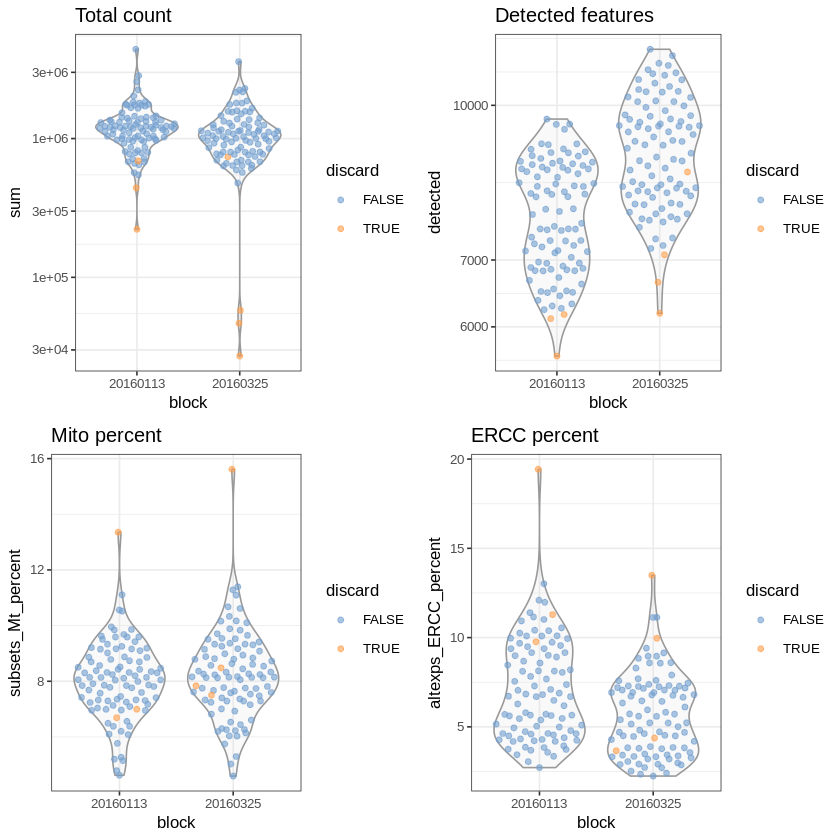

In [10]:
library(gridExtra) # Load the gridExtra package
library(scater)
gridExtra::grid.arrange(
  plotColData(unfiltered, x="block", y="sum",
     colour_by="discard") + scale_y_log10() + ggtitle("Total count"),
  plotColData(unfiltered, x="block", y="detected",
     colour_by="discard") + scale_y_log10() + ggtitle("Detected features"),
  plotColData(unfiltered, x="block", y="subsets_Mt_percent",
     colour_by="discard") + ggtitle("Mito percent"),
  plotColData(unfiltered, x="block", y="altexps_ERCC_percent",
     colour_by="discard") + ggtitle("ERCC percent"),
  nrow=2,
  ncol=2
)

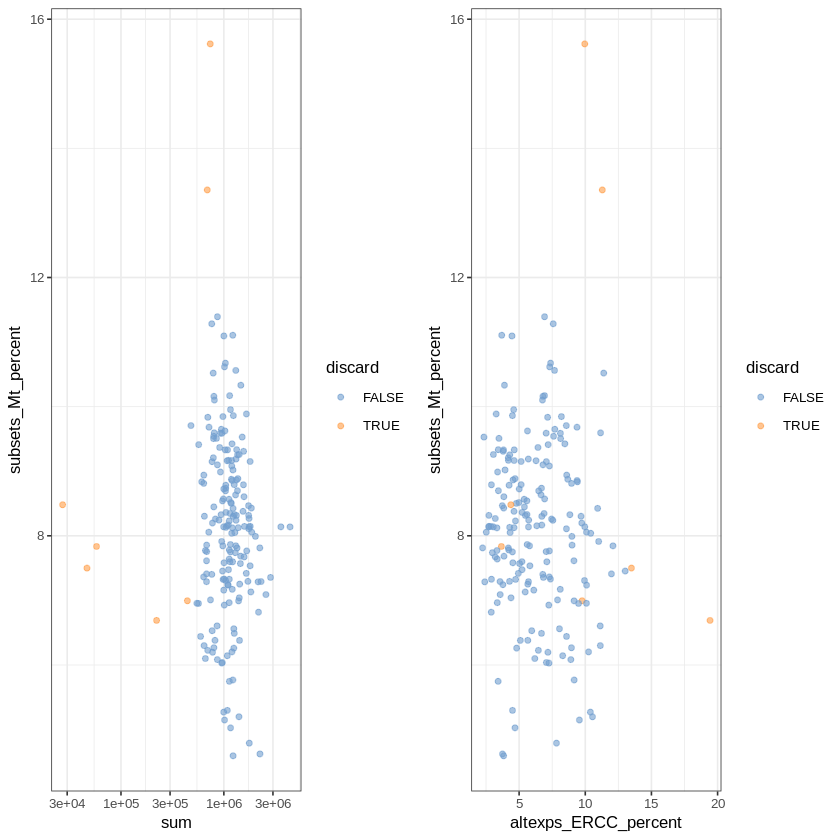

In [11]:
gridExtra::grid.arrange(
  plotColData(unfiltered, x="sum", y="subsets_Mt_percent",
     colour_by="discard") + scale_x_log10(),
  plotColData(unfiltered, x="altexps_ERCC_percent", y="subsets_Mt_percent",
     colour_by="discard"),
 ncol=2
)

In [12]:
colSums(as.matrix(qc))

low_lib_size            low_n_features   high_subsets_Mt_percent 
                        5                         0                         2 
high_altexps_ERCC_percent                   discard 
                        2                         7

##**Normalization**

In [13]:
BiocManager::install("scran")
library(scran)
sce.416b <- scran::computeSumFactors(sce.416b)
sce.416b <- logNormCounts(sce.416b)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'scran'"
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgdown',
  'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny',
  'survival', 'tinytex', 'urlchecker', 'withr', 'xfun', 'xml2', 'xtable', 'zip'


Attaching package: 'scran'


The following object is masked from 'package:scrapper':

    scoreMarkers


Warning message in .local(x, ...):
"'normalizeCounts' is deprecated.
Use 'scrapper::normalizeCounts' instead.
See help("Deprecated")"


In [14]:
summary(sizeFactors(sce.416b))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3468  0.7111  0.9207  1.0000  1.1520  3.6037 

Warning message in .library_size_factors(assay(x, assay.type), ...):
"'librarySizeFactors' is deprecated.
Use 'scrapper::centerSizeFactors' instead.
See help("Deprecated")"


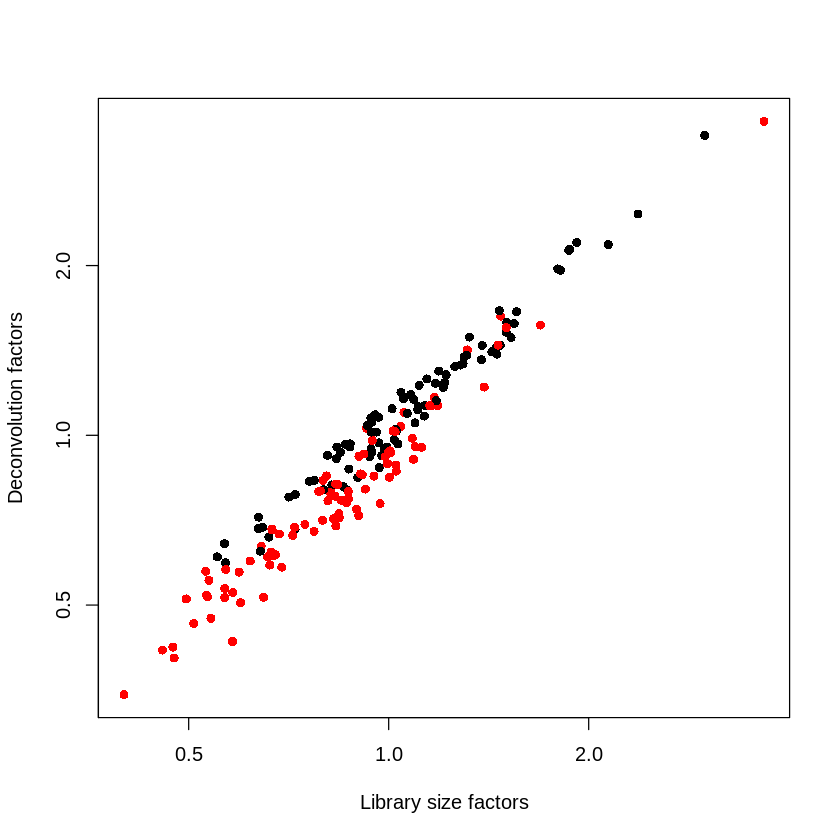

In [15]:
plot(librarySizeFactors(sce.416b), sizeFactors(sce.416b), pch=16,
   xlab="Library size factors", ylab="Deconvolution factors",
   col=c("black", "red")[grepl("induced", sce.416b$phenotype)+1],
   log="xy")

##**Variance Modelling**

Warning message in .model_gene_var_with_spikes(x = assay(x, i = assay.type), ...):
"'modelGeneVarWithSpikes' is deprecated.
See help("Deprecated")"
Warning message in .local(x, ...):
"'librarySizeFactors' is deprecated.
Use 'scrapper::centerSizeFactors' instead.
See help("Deprecated")"
Warning message in fitTrendVar(fm, fv, ...):
"'fitTrendVar' is deprecated.
Use 'scrapper::fitVarianceTrend' instead.
See help("Deprecated")"
Warning message in fitTrendVar(fm, fv, ...):
"'fitTrendVar' is deprecated.
Use 'scrapper::fitVarianceTrend' instead.
See help("Deprecated")"
Warning message in combineBlocks(collected, method = method, equiweight = equiweight, :
"'combineBlocks' is deprecated.
See help("Deprecated")"
Warning message in getTopHVGs(dec.416b, prop = 0.1):
"'getTopHVGs' is deprecated.
Use 'scrapper::chooseHighlyVariableGenes' instead.
See help("Deprecated")"


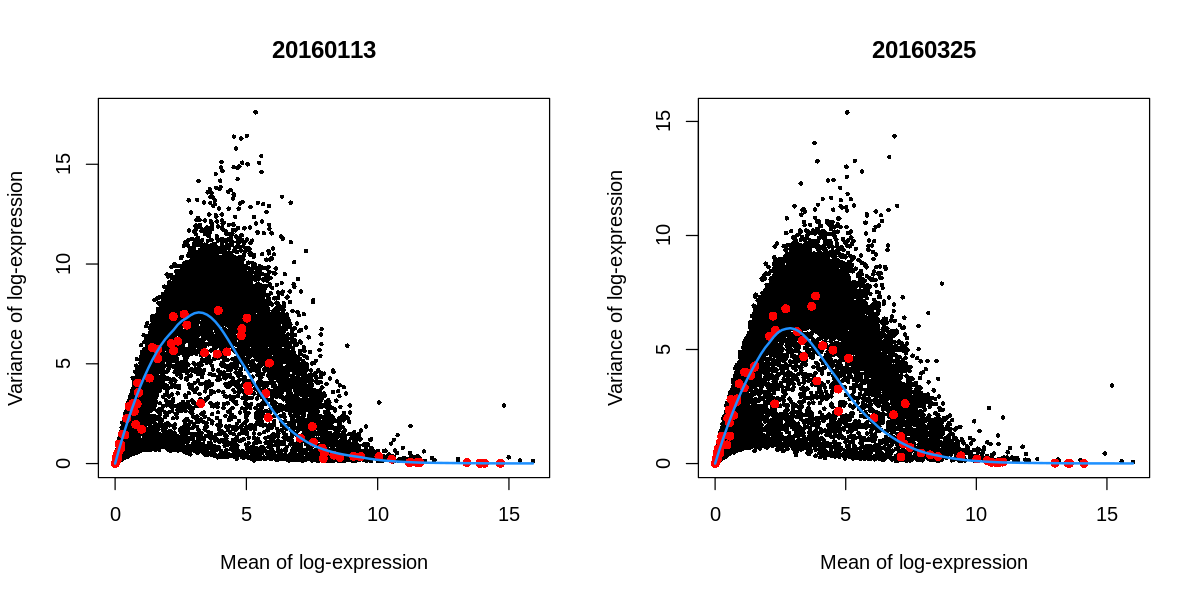

In [16]:
dec.416b <- modelGeneVarWithSpikes(sce.416b, "ERCC", block=sce.416b$block)
chosen.hvgs <- getTopHVGs(dec.416b, prop=0.1)
par(mfrow=c(1,2))
blocked.stats <- dec.416b$per.block
for (i in colnames(blocked.stats)) {
  current <- blocked.stats[[i]]
  options(repr.plot.width=10, repr.plot.height=5)
  plot(current$mean, current$total, main=i, pch=16, cex=0.5,
  xlab="Mean of log-expression", ylab="Variance of log-expression")
  curfit <- metadata(current)
  points(curfit$mean, curfit$var, col="red", pch=16)
  curve(curfit$trend(x), col='dodgerblue', add=TRUE, lwd=2)
}

##**Batch correction**

In [17]:
library(limma)
assay(sce.416b, "corrected") <- removeBatchEffect(logcounts(sce.416b),
   design=model.matrix(~sce.416b$phenotype), batch=sce.416b$block)


Attaching package: 'limma'


The following object is masked from 'package:scater':

    plotMDS


The following object is masked from 'package:BiocGenerics':

    plotMA




##**Dimensionality reduction**

In [18]:
sce.416b <- runPCA(sce.416b, ncomponents=10, subset_row=chosen.hvgs,
exprs_values="corrected", BSPARAM=BiocSingular::ExactParam())

set.seed(1010)
sce.416b <- runTSNE(sce.416b, dimred="PCA", perplexity=10)

Clustering

In [19]:
my.dist <- dist(reducedDim(sce.416b, "PCA"))
my.tree <- hclust(my.dist, method="ward.D2")

BiocManager::install("dynamicTreeCut")
library(dynamicTreeCut)
my.clusters <- unname(cutreeDynamic(my.tree, distM=as.matrix(my.dist),
                                                             minClusterSize=10, verbose=0))
colLabels(sce.416b) <- factor(my.clusters)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'dynamicTreeCut'"
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgdown',
  'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny',
  'survival', 'tinytex', 'urlchecker', 'withr', 'xfun', 'xml2', 'xtable', 'zip'



In [20]:
table(Cluster=colLabels(sce.416b), Plate=sce.416b$block)

       Plate
Cluster 20160113 20160325
      1       40       38
      2       37       32
      3       10       14
      4        6        8

In [21]:
table(Cluster=colLabels(sce.416b), Oncogene=sce.416b$phenotype)

       Oncogene
Cluster induced CBFB-MYH11 oncogene expression wild type phenotype
      1                                     78                   0
      2                                      0                  69
      3                                      1                  23
      4                                     14                   0

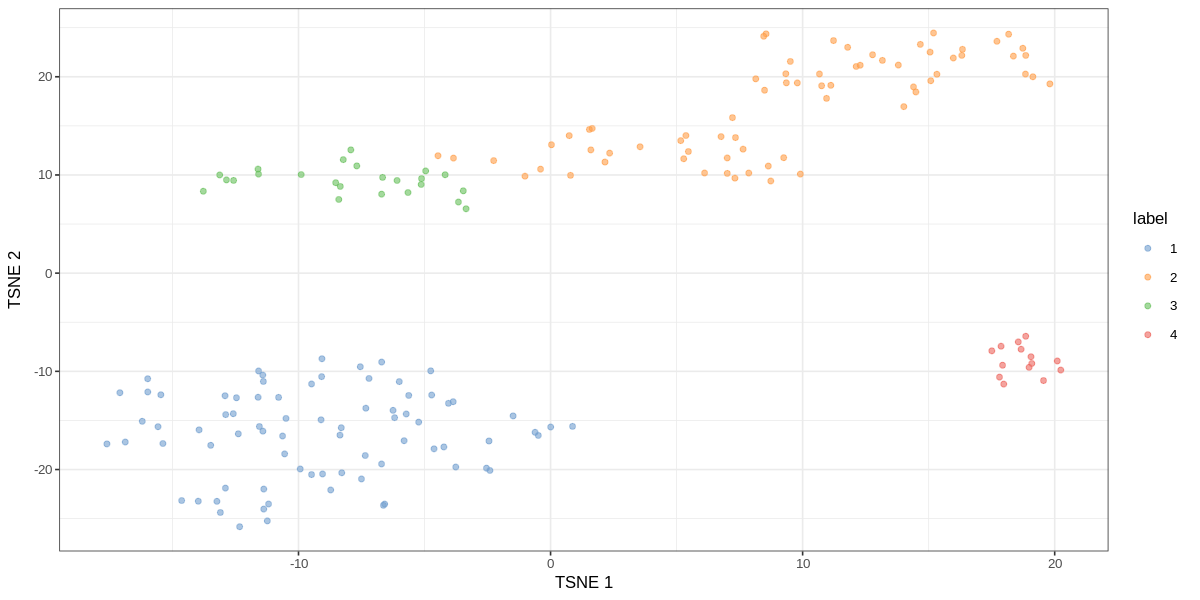

In [22]:
plotTSNE(sce.416b, colour_by="label")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'cluster'

Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgdown',
  'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny',
  'survival', 'tinytex', 'urlchecker', 'withr', 'xfun', 'xml2', 'xtable', 'zip'



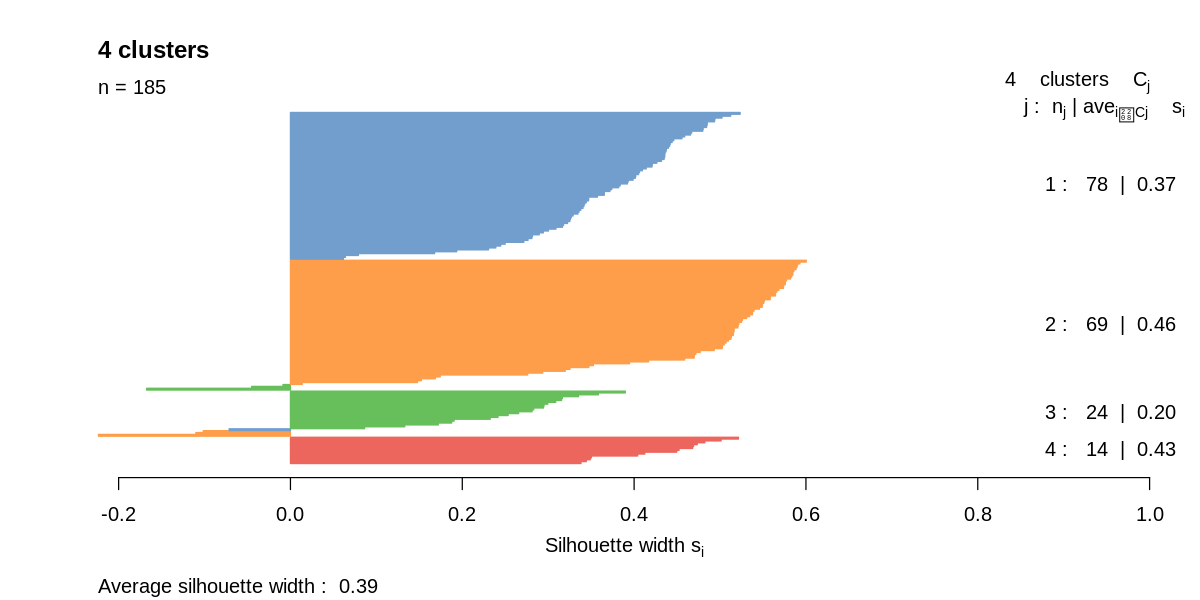

In [23]:
BiocManager::install(("cluster"), force=TRUE)
library(cluster)
options(repr.plot.width=10, repr.plot.height=5)
clust.col <- scater:::.get_palette("tableau10medium") # hidden scater colours
sil <- silhouette(my.clusters, dist = my.dist)
sil.cols <- clust.col[ifelse(sil[,3] > 0, sil[,1], sil[, 2])]
sil.cols <- sil.cols [order(-sil[,1], sil[, 3])]
plot(sil, main = paste (length(unique (my.clusters)), "clusters"),
                                       border=sil.cols, col=sil.cols, do.col.sort=FALSE)

Interpretation

In [24]:
markers <- findMarkers(sce.416b, my.clusters, block=sce.416b$block)
marker.set <- markers[["1"]]
head(marker.set, 10)

Warning message in .findMarkers(assay(x, i = assay.type), ...):
"'findMarkers' is deprecated.
Use 'scrapper::scoreMarkers.se' instead.
See help("Deprecated")"
Warning message in .local(x, ...):
"'pairwiseTTests' is deprecated.
See help("Deprecated")"
Warning message in combineMarkers(fit$statistics, fit$pairs, pval.type = pval.type, :
"'combineMarkers' is deprecated.
Use 'scrapper::summarizeEffects' instead.
See help("Deprecated")"


DataFrame with 10 rows and 7 columns
            Top     p.value         FDR summary.logFC   logFC.2   logFC.3
      <integer>   <numeric>   <numeric>     <numeric> <numeric> <numeric>
Ccna2         1 9.85422e-67 4.59246e-62      -7.13310  -7.13310  -2.20632
Cdca8         1 1.01449e-41 1.52514e-38      -7.26175  -6.00378  -2.03841
Pirb          1 4.16555e-33 1.95516e-30       5.87820   5.28149   5.87820
Cks1b         2 2.98233e-40 3.23229e-37      -6.43381  -6.43381  -4.15385
Aurkb         2 2.41436e-64 5.62593e-60      -6.94063  -6.94063  -1.65534
Myh11         2 1.28865e-46 3.75353e-43       4.38182   4.38182   4.29290
Mcm6          3 1.15877e-28 3.69887e-26      -5.44558  -5.44558  -5.82130
Cdca3         3 5.02047e-45 1.23144e-41      -6.22179  -6.22179  -2.10502
Top2a         3 7.25965e-61 1.12776e-56      -7.07811  -7.07811  -2.39123
Mcm2          4 1.50854e-33 7.98908e-31      -5.54197  -5.54197  -6.09178
         logFC.4
       <numeric>
Ccna2 -7.3451052
Cdca8 -7.2617478
Pirb   

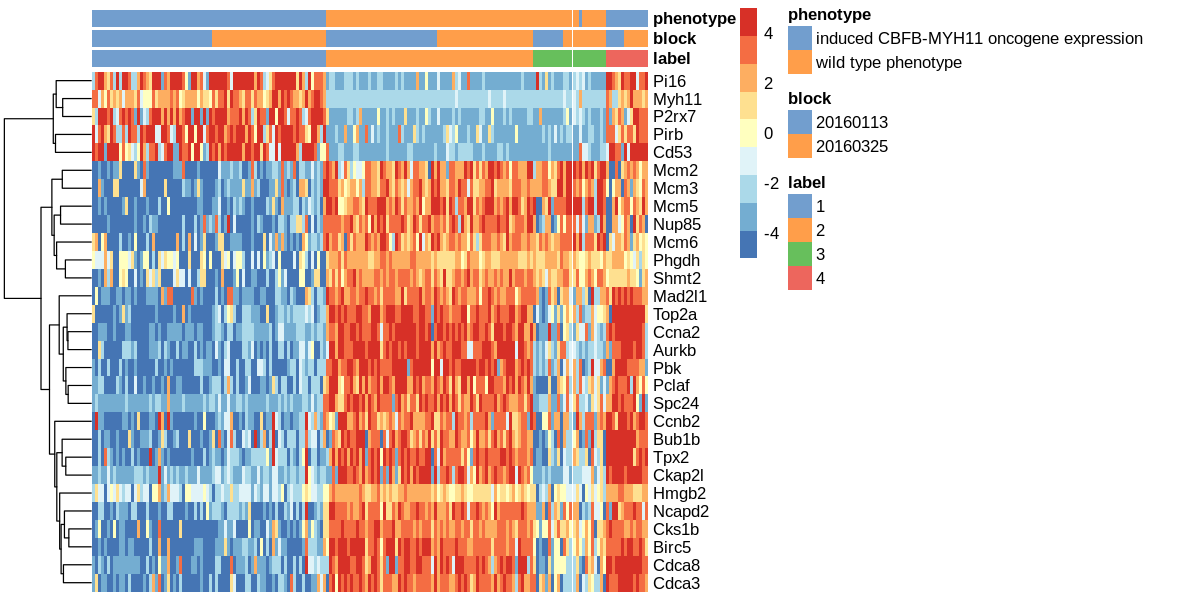

In [25]:
options(repr.plot.width = 10, repr.plot.height = 5)
top.markers <- rownames(marker.set)[marker.set$Top <=10]
plotHeatmap(sce.416b, features=top.markers, order_columns_by="label",
            colour_columns_by=c("label", "block", "phenotype"),
            center=TRUE, symmetric=TRUE, zlim=c(-5, 5))